# Warehouse location optimization problem as an MILP problem

Given below is the R code for Warehouse facility location optimization problem using packages like `ompr`, `ompr.roi`, `ROI.plugin.symphony` which are dedicated to solve ***Mixed Integer Linear Programming*** models.
Here we use some simulated locations but it can be easily generalised to real world locations to some extend. Although there are some general assumptions in the generalised model as well, which we shall discuss at the end.




**The embeded report: file can be viewed as below** 👇


In [ ]:
install.packages("IRdisplay")
library(IRdisplay)
f_id <- "1iajsmH2rio58j98OWVhiPR1mizElMxBk"
embed_url <- paste0("https://drive.google.com/file/d/",f_id,"/preview")
display_html(sprintf('<iframe src="%s" width="700" height="500"></iframe>', embed_url))


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Install & load libraries
# install.packages(c("readr","dplyr","ompr","ompr.roi","ROI.plugin.symphony","ggplot2"))
#library(readr)      # for larger files; for faster I/O
library(dplyr)
library(ompr);   library(ompr.roi)
library(ROI.plugin.symphony)
library(ggplot2)


# Create some sample points in R
set.seed(123456)                     # may do it to generate same solution

# Demand points: 10 cities
demandpt <- data.frame(
  id = sprintf("Loc_%02d", 1:50),
  x  = runif(50,  0, 100),
  y  = runif(50,  0, 100)
)

# Warehouse candidates: 5 sites
warehouses <- data.frame(
  id   = sprintf("WH_%02d", 1:7),
  x    = runif(7,  0, 100),
  y    = runif(7,  0, 100)
)

# Write them out as CSVs in your working directory
write.csv(demandpt,      "demandpt.csv",      row.names = FALSE)
write.csv(warehouses,  "warehouses.csv",  row.names = FALSE)

# Now you can verify
# list.files(pattern = "\\.csv$")
# [1] "demand.csv"      "warehouses.csv"



# 1. Read your CSVs of coordinates # if using readr
# demand.csv: columns id,x,y
# warehouses.csv: columns id,x,y
#demand    <- read.csv("demand.csv",    col_types = cols())
#warehouses<- read.csv("warehouses.csv",col_types = cols())

# Read CSVs without converting strings to factors (without readr package)
demandpt   <- read.csv("demandpt.csv",     stringsAsFactors = FALSE)
warehouses <- read.csv("warehouses.csv", stringsAsFactors = FALSE)

# (Optional) If you need certain columns as numeric/integer:
# demand$lambda <- as.numeric(demand$lambda)
# warehouses$cost <- as.numeric(warehouses$cost)


# 2. Generate expected demand lambda_k via Poisson means
# Here we assign each demand point a random mean in [50,200]
set.seed(1293)
demandpt <- demandpt %>%
  mutate(demand = runif(n(), 50, 200))  # expected demand
# even if the demand may follow some pois(lambda) the E[demand] = lambda
# so we may generate a random sample of lambda within some range.



#-----------------this is the general model--------------------------------

# 3. Compute distance matrix c[k,j] (Euclidean)
coords_d <- demandpt  %>% select(x,y) %>% as.matrix()
coords_w <- warehouses%>% select(x,y) %>% as.matrix()
# function to compute distance matrix
dist_mat <- as.matrix(dist(rbind(coords_d, coords_w)))
K <- nrow(demandpt); J <- nrow(warehouses)
c_mat <- dist_mat[1:K, (K+1):(K+J)]  # K×J


# 4. Set up parameters for optimization
I_idx <- 1:K
J_idx <- 1:J

lambda  <- demandpt$demand      # length K
F  <- rep(1000, J)              # fixed cost per warehouse (or customize)
M  <- rep(sum(lambda), J)       # big-M capacity (uncapacitated)


# 5. Build & solve the MILP via ompr
model <- MIPModel() %>%
  # decision vars
  add_variable(y[j], j = J_idx,             type = "binary")         %>%
  add_variable(x[i,j], i = I_idx, j = J_idx, lb = 0, type = "continuous") %>%

  # demand satisfaction
  add_constraint(sum_expr(x[i,j], j = J_idx) == lambda[i], i = I_idx)      %>%

  # capacity constraint
  add_constraint(sum_expr(x[i,j], i = I_idx) <= M[j] * y[j], j = J_idx) %>%

  # strong linking
  add_constraint(x[i,j] <= lambda[i] * y[j], i = I_idx, j = J_idx)         %>%

  # objective: fixed + transport
  set_objective(
    sum_expr(F[j] * y[j], j = J_idx) +
      sum_expr(c_mat[i,j] * x[i,j], i = I_idx, j = J_idx),
    "min"
  )

result <- solve_model(model, with_ROI("symphony", verbosity = 1))


# 6. Extract solution
y_sol <- get_solution(result, y[j]) %>% filter(value > 1e-6)
x_sol <- get_solution(result, x[i,j]) %>% filter(value > 1e-6)

open_wh   <- y_sol$j
assign_df <- x_sol %>%
  mutate(
    cust = i,
    wh   = j
  ) %>%
  select(cust, wh)

cat("Optimal cost:", objective_value(result), "\n")
cat("Warehouses opened:", toString(open_wh), "\n")


# 7. Plot with ggplot2
# 7a. annotate demandpt and warehouse dfs
d2 <- demandpt %>% mutate(cust = row_number())
w2 <- warehouses %>% mutate(wh = row_number(),
                            status = ifelse(wh %in% open_wh, "Open","Closed"))

# 7b. build segment data
segs <- assign_df %>%
  left_join(d2, by = c("cust"="cust")) %>%
  left_join(w2, by = c("wh"="wh"),
            suffix = c(".cust", ".wh"))

ggplot() +
  geom_segment(data = segs,
               aes(x = x.wh, y = y.wh,
                   xend = x.cust, yend = y.cust),
               linetype="dashed", color="gray60") +
  geom_point(data = d2,
             aes(x = x, y = y), color="blue", size=2) +
  geom_point(data = w2,
             aes(x = x, y = y, color = status, shape = status),
             size=4) +
  scale_color_manual(values = c(Open="red",Closed="black")) +
  scale_shape_manual(values = c(Open=17,Closed=16)) +
  labs(title = "Facility Location Solution",
       subtitle = paste0("Opened=", toString(open_wh)),
       x="X", y="Y") +
  theme_minimal() +
  coord_equal()

Demand location coordinates along with expected demands
```
# Demand points
       id         x          y    demand
1  Loc_01 79.778432 33.4557457 145.58377
2  Loc_02 75.356509 74.8855999 150.78195
3  Loc_03 39.125568 50.6616552 182.76490
4  Loc_04 34.155670 86.2259152 185.17364
5  Loc_05 36.129411 75.9557256  79.74862
6  Loc_06 19.834473 96.4383255 168.35301
7  Loc_07 53.485796 83.4437237  54.04798
8  Loc_08  9.652624 83.7036932  57.29592
9  Loc_09 98.784694 26.7467090 145.86200
10 Loc_10 16.756948 17.5932494 192.65124
11 Loc_11 79.798913 19.6035676 134.39537
12 Loc_12 59.379402  1.9580189 194.06291
13 Loc_13 90.531001 52.7727398 199.82003
14 Loc_14 88.084865 18.1629571 166.50466
15 Loc_15 99.383655 14.7734747 113.38150
16 Loc_16 89.595634 59.0974018 193.67875
17 Loc_17 87.864335  0.2990070  72.07203
18 Loc_18 19.760575 36.1016099 144.54105
19 Loc_19 33.499360 12.9267699  84.20247
20 Loc_20 77.720632  1.4579048  79.84077
21 Loc_21 15.959356 19.4430504  51.56925
22 Loc_22  8.064525 64.8670685 182.47401
23 Loc_23 13.265034 94.0628788  64.03246
24 Loc_24 17.190540 34.6356111  80.29949
25 Loc_25 47.777784 84.4968148 123.16501
26 Loc_26 70.050477 12.9383537 138.57820
27 Loc_27 87.988906 85.1756020 189.38374
28 Loc_28 87.779368 21.8427168 121.82942
29 Loc_29 85.387959 13.2231356 165.80129
30 Loc_30 16.598752 62.1454719  83.59005
31 Loc_31 52.296875 14.2016269  66.30893
32 Loc_32 86.912820  0.1311457  92.45122
33 Loc_33 23.115669 83.3433097 153.19683
34 Loc_34 11.908091 94.5494323 129.21941
35 Loc_35 82.395123 56.7900916  51.75041
36 Loc_36  8.027698 40.1693776  73.15832
37 Loc_37 95.236307 18.5059548 170.87817
38 Loc_38 87.161736 54.7540751  98.23214
39 Loc_39 71.215382 56.2885564  96.28106
40 Loc_40 60.540451 16.0966964  67.36031
41 Loc_41 22.543218 30.7851881 122.74481
42 Loc_42 73.959514 35.9530449  86.53574
43 Loc_43 89.554245 16.7041455 132.71790
44 Loc_44 29.446324 19.3425931 187.55196
45 Loc_45 51.535252 45.4724279 129.55423
46 Loc_46 43.464955  3.9457683  83.69194
47 Loc_47 57.516512 86.1249396 139.71422
48 Loc_48 74.095602 76.8159446  90.34531
49 Loc_49 67.817263 11.2823530  63.88265
50 Loc_50 36.201619 39.5910402  87.00896
```


Possible Warehouse location coordinates
```
# Possible warehouse locations
     id         x         y
1 WH_01  3.855369  5.837738
2 WH_02 65.944752 93.788305
3 WH_03 31.146853 61.933480
4 WH_04 18.956915 36.709074
5 WH_05 62.607131  5.811437
6 WH_06 51.671846 14.063992
7 WH_07 92.794573 40.135774
```


# Solution
```
Optimal cost: 119841.5
Warehouses opened: 2, 3, 4, 5, 6, 7
```

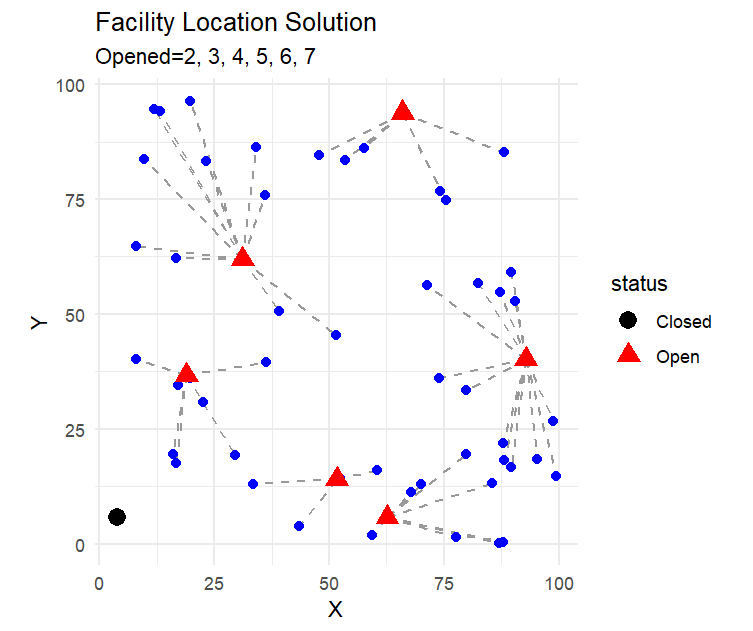


```
# Demand points
        id        x         y    lambda
1  Loc_01 35.54454  4.766363  93.13663
2  Loc_02 53.36879 70.085309 168.24577
3  Loc_03 74.03344 35.188864 111.34654
4  Loc_04 22.11029 40.894400 182.45261
5  Loc_05 41.27461 82.095132 191.07009
6  Loc_06 26.56867 91.885735  56.83347
7  Loc_07 62.99731 28.252833 129.21582
8  Loc_08 18.38285 96.110479 183.86286
9  Loc_09 86.36441 72.839443 132.71525
10 Loc_10 74.65680 68.637508 118.49221
11 Loc_11 66.82846  5.284394 193.52500
12 Loc_12 61.80179 39.522013 118.00012
13 Loc_13 37.22381 47.784538 151.63560
14 Loc_14 52.98357 56.025326 135.89501
15 Loc_15 87.46823 69.826159  65.43870
16 Loc_16 58.17501 91.568354 184.97375
17 Loc_17 83.97678 61.835123  86.91316
18 Loc_18 31.24482 42.842151  56.30893
19 Loc_19 70.82903 54.208037  99.18811
20 Loc_20 26.50178  5.847849 193.17555
21 Loc_21 59.43432 26.085686 183.43090
22 Loc_22 48.12898 39.715195 153.92051
23 Loc_23 26.50327 19.774474 146.07602
24 Loc_24 56.45904 83.192756 199.14047
25 Loc_25 91.31882 15.288722 148.35587
26 Loc_26 90.18744 80.341854 156.27957
27 Loc_27 27.41666 54.682616 131.60990
28 Loc_28 32.14828 66.231764 139.12130
29 Loc_29 98.56409 17.169849  93.37396
30 Loc_30 61.99933 63.305536  72.06705
31 Loc_31 93.73141 31.186975 194.45363
32 Loc_32 46.65327 72.455435 185.34486
33 Loc_33 40.68326 39.893982 153.60579
34 Loc_34 65.92303 96.935641 169.32011
35 Loc_35 15.23466 96.739837  53.69205
36 Loc_36 57.28671 72.670254 121.66940
37 Loc_37 23.87260 25.721675 163.76893
38 Loc_38 96.23589 22.178793  82.46119
39 Loc_39 60.13657 59.304565  97.72715
40 Loc_40 51.50297 26.752143  84.74387
41 Loc_41 40.25733 53.107040  71.42000
42 Loc_42 88.02465 78.529167 112.18195
43 Loc_43 36.40919 16.806081 112.05865
44 Loc_44 28.82393 40.439918 105.32682
45 Loc_45 17.06452 47.157628  72.86671
46 Loc_46 17.21717 86.810681  70.82091
47 Loc_47 48.20426 92.570796  84.95511
48 Loc_48 25.29649 88.197756 119.89437
49 Loc_49 21.62548 67.418684  89.89590
50 Loc_50 67.43764 95.016698 178.67416
```
```
# Possible warehouse locations
    id        x          y
1 WH_01 51.64449  0.6300784
2 WH_02 57.65190  7.2057124
3 WH_03 33.63312 16.4211225
4 WH_04 34.73246 77.0334074
5 WH_05  2.00243 73.5184306
6 WH_06 50.28130 97.1875636
7 WH_07 87.10434 46.6472377
```
```
# Optimal cost: 132200.6
# Warehouses opened: 2, 3, 4, 6, 7
```

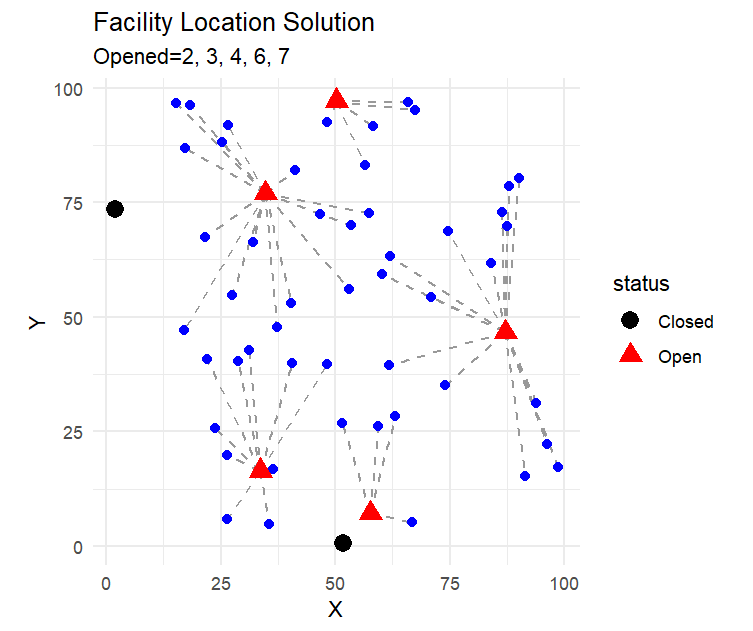

# Naive Approach (All warehouse open)
The following code generates the total cost that occurs due to forcefully openning all the warehouse facilities. This is for comparison.

In [ ]:
library(ompr)
library(ompr.roi)
library(ROI.plugin.symphony)
library(dplyr)

set.seed(42)
# Read data
warehouses <- read.csv("warehouses.csv")
demand <- read.csv("demand.csv")

n_warehouses <- nrow(warehouses)
n_demand <- nrow(demand)

# Compute transportation cost matrix (distance * cost_per_km)
cost_per_km <- 10
distance_matrix <- as.matrix(dist(rbind(warehouses[, c("x", "y")], demand[, c("x", "y")])))
transport_cost <- cost_per_km * distance_matrix[1:n_warehouses, (n_warehouses + 1):(n_warehouses + n_demand)]

# Build naive model (force all y[j] = 1)
model_naive <- MIPModel() %>%
  add_variable(x[i, j], i = 1:n_demand, j = 1:n_warehouses, type = "continuous", lb = 0) %>%
  set_objective(
    sum_expr(x[i, j] * transport_cost[j, i], i = 1:n_demand, j = 1:n_warehouses) +
      sum_expr(1e6, j = 1:n_warehouses), "min"
  ) %>%
  add_constraint(
    sum_expr(x[i, j], j = 1:n_warehouses) == demand$demand[i], i = 1:n_demand
  )

# Solve the naive model
result_naive <- solve_model(model_naive, with_ROI(solver = "symphony", verbosity = -2))

# Get cost
naive_cost <- objective_value(result_naive)
cat(sprintf("Naive approach cost (all warehouses open): ", naive_cost))


The following is the output for the first scenario mentioned in the project report under the Analysis section; 5 candidate warehouses resulting into 2 open warehouses with optimal cost 4,753.28 (in scaled units).   

```
Naive approach cost (all warehouse open): 5,730.15
```



# Limitations

This generalised model has some assumptions and limitations:
1.  Deterministic demand:
 * Using the mean of Poisson distributions as demand inputs (λ) and treating it as fixed.
    
 * Limitation: Real-world demand is uncertain. Ignoring variability can lead to underprovisioning or overprovisioning.

2.  Euclidean distances & Linear transportation costs:
 * We are using Euclidean distance to be proportional to the transportation cost.

 * Limitation: Real logistics costs are not linear in distance—there are:
Fixed trip costs, road networks, fuel cost structures. Also road distances are not Euclidean and we are not taking into account the spherical nature of Earth. (Though, it would not cause a lot of trouble due to the fact that we are concerned about major cities of a country so when considering more than 1 city transportation will not occur between these cities. So using Euclidean distances won't change the results much.)

3. Single commodity (no product types):
  * Each demand point has a single demand quantity.

  * Limitation: Real facility problems often involve multiple products, each with its own volume, handling needs, and constraints.

4. Homogeneous warehouses & Capacity as big-M
  * All warehouses have same fixed cost ```(F[j] = 1000)``` and capacity ```(M[j] = sum(λ))``` for all warehouses, effectively uncapacitated type problem, i.e, the storage capacity of the warehouses are such all demands are met. And here the expected demands are in decimals.

  * Limitation: Real warehouses differ in: Capacity, operating cost, availability, specialization.

5. No penalties for unserved demand:
   *  We assume all demand is always met.

   *  Limitation: In emergencies, stockouts may happen, and the model should consider penalties or backorders.

6. No economies of scale or congestion:
  * Cost to serve is proportional to demand times distance.

  * Limitation: Large consolidated shipments are often cheaper per unit (economies of scale), while warehouses can also become congested, increasing cost.

7. No time windows or delivery schedules:
  * The model does not consider time-sensitive deliveries.

  * Limitation: In logistics, delivery time, service level, and cutoff times matter.
  * There exists various vehicle routing problem—VRP algorithms that can shorten the time window and finding efficient routes.

8. Static model:
  * We solve the problem for a single period.

  * Limitation: Demand and operations evolve over time.

9. Bugdet constraints:
   *   We assume that the possible warehouse locations are chosen such that they never cross some fixed budget allocated for them.
   *  Limitation: We have not directly considered the bugdet allocation which is unrealistic but it can be easily solved by adding one more constraint in our MILP
\begin{aligned}
\min_{x,y}\;&\sum_{j=1}^J F_j\,y_j \;+\;\sum_{i=1}^K\sum_{j=1}^J c_{ij}\,x_{ij} \\
\text{s.t.}\quad
&\sum_{j=1}^J x_{ij} = \lambda_i, \quad &&i=1,\dots,K, \\
&\sum_{i=1}^K x_{ij} \le M_j\,y_j, \quad &&j=1,\dots,J, \\
&x_{ij} \le \lambda_i\,y_j, \quad &&i=1,\dots,K,\;j=1,\dots,J, \\
&\sum_{j=1}^J F_j\,y_j \;\le\; B, \quad &&(\text{budget constraint})\\
&y_j\in\{0,1\},\;x_{ij}\ge0.
\end{aligned}

